In [1]:
# import modules
import numpy as np
import random
import math
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import sys
import matplotlib.pyplot as plt
from tqdm import tqdm
from time import time
import tensorflow as tf
import tensorflow_probability as tfp
tfd = tfp.distributions
tfb = tfp.bijectors

np.set_printoptions(suppress=True)
import warnings
warnings.filterwarnings('ignore')

2024-01-31 17:53:36.409763: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-01-31 17:53:36.409824: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-01-31 17:53:36.409842: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-01-31 17:53:36.416411: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


**Gaussian random field**

In [2]:
# First generate some synthetic data
# Generate random covariate fields
# We use 2 simulated covariates

L = 50.0 # size of domain
x = y = np.arange(0,L+1,1)
var=1.0

2024-01-31 17:53:47.006843: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14638 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0001:00:00.0, compute capability: 7.5
2024-01-31 17:53:47.223421: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-01-31 17:53:47.744673: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x56395ad448f0


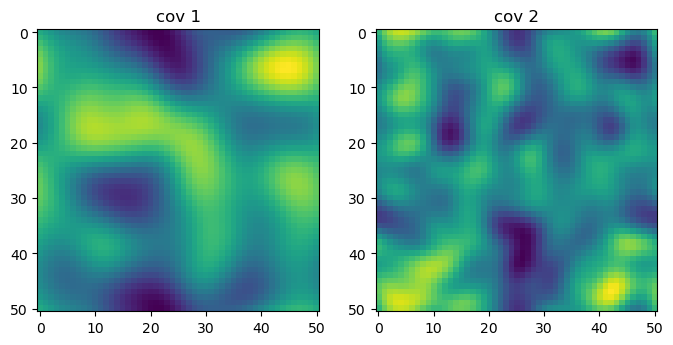

In [3]:
# Make the environment using a correlated periodic Gaussian random field

x = y = np.arange(0,L+1,1)
xx, yy = np.meshgrid(x,y)

positions = np.vstack([xx.ravel(), yy.ravel()]).T

len_scale_1 =10 #5
period = np.float64(L)
periodic_len = (2**0.5)*len_scale_1*np.pi/period


kernel = tfp.math.psd_kernels.ExpSinSquared(length_scale=periodic_len,period=period)
gp = tfd.GaussianProcess(kernel, positions)

samples = gp.sample()
cov1 = samples.numpy().reshape(51,51)


len_scale_2 =5 #10
period = np.float64(L)
periodic_len = (2**0.5)*len_scale_2*np.pi/period


kernel = tfp.math.psd_kernels.ExpSinSquared(length_scale=periodic_len,period=period)
gp = tfd.GaussianProcess(kernel, positions)

samples = gp.sample()
cov2 = samples.numpy().reshape(51,51)

fig, ax = plt.subplots(1,2,figsize=(8,6))
ax[0].set_title('cov 1')
ax[0].imshow(cov1)
ax[1].set_title('cov 2')
ax[1].imshow(cov2)
plt.show()

cov_cube = np.stack((cov1,cov2))

**Data generation**

In [4]:
# Simulating observation from centred model

nbObs=10001 #nbObs Number of observations
beta=np.array([[-1.5,-1.8]]) # Vector of resource selection coefficients
allr=np.ones(nbObs) # Vector of radii for movement kernel, or standard deviations
cov=cov_cube #Array of covariates (one layer for each covariate)
xy0=[25,25] #Initial location
npts=100 # Number of potential endpoints to sample at each time step
xy1=np.zeros((nbObs,2))
xy1[0] = xy0
x_min = [0., 0.]
x_max = [L, L]

# Convert the covariates to tensor
cov_tensor = tf.transpose(tf.convert_to_tensor(cov_cube,dtype=tf.float32),[2,1,0])
beta_tensor = tf.convert_to_tensor(beta,dtype=tf.float32)

C=np.zeros((2))
allrsf=np.zeros(npts)
dt = np.zeros(nbObs)
ID = np.zeros(nbObs)
cid=0
t = 1
for t in tqdm(range(1,nbObs)):
    cdt = np.random.normal(loc=1.0,scale=0.1)
    C[0] = np.random.normal(loc=xy1[t-1,0],scale=allr[t-1]*((0.5*cdt)**0.5))
    C[1] = np.random.normal(loc=xy1[t-1,1],scale=allr[t-1]*((0.5*cdt)**0.5))

    grid=np.zeros((npts,2))
    # sample npts points in the circle

    grid[:,0]=np.random.normal(loc=C[0], scale=allr[t-1]*((0.5*cdt)**0.5),size=npts)
    grid[:,1]=np.random.normal(loc=C[1], scale=allr[t-1]*((0.5*cdt)**0.5),size=npts)

    # Convert grid to tensor before extracting the values
    zgrid=tf.convert_to_tensor(grid%L,dtype=tf.float32)

    # calculate the covariates at the step end locations using tensorflow probability
    cov_xy_end = tfp.math.batch_interp_regular_nd_grid(zgrid, x_min, x_max, cov_tensor, axis=-3)

    # calculate the rsf
    allrsf= np.array(tf.exp(tf.reduce_sum(tf.multiply(cov_xy_end,beta_tensor),axis=-1)))

    next_point=random.choices(population=grid,weights=allrsf,k=1)

    dt[t-1]=cdt
    xy1[t]=next_point[0]

    ID[t]=cid

100%|██████████| 10000/10000 [02:00<00:00, 83.03it/s]


**Data processing**

In [5]:
# preprocessing steps convert to tensors and handle the change of ID, start/end points and time between fixes
start_points = []
end_points = []
step_times = []
for i in np.unique(ID):
    cxy = xy1[ID==i]#[:1024*100+1]
    cdt = dt[ID==i]#[:1024*100+1]
    if cdt.shape[0]<2:
        continue
    start_points.append(cxy[:-1])
    end_points.append(cxy[1:])
    step_times.append(np.atleast_2d(cdt[:-1]).T)


indexes = np.arange(np.vstack(start_points).shape[0])
np.random.shuffle(indexes)
start_points = tf.convert_to_tensor(np.vstack(start_points)[indexes],dtype=tf.float32)
end_points = tf.convert_to_tensor(np.vstack(end_points)[indexes],dtype=tf.float32)
step_times = tf.convert_to_tensor(np.vstack(step_times)[indexes],dtype=tf.float32)


cov_tensor = tf.transpose(tf.convert_to_tensor(cov_cube,dtype=tf.float32),[2,1,0])

x_ref_min = [0., 0.]
x_ref_max = [L, L]

**Variational Inference**

In [ ]:
# A periodic version for working with simulated data on a torus

class stepSelectionVI(tf.Module):
    def __init__(self, n_covars, cov_tensor, move_std=1.0, L=1.0,  prior_mean=None, prior_std=None,n_gh_points=4,n_vi_samples=4):


        self.n_covars = n_covars
        self.cov_tensor = cov_tensor
        self.n_gh_points = n_gh_points
        self.n_vi_samples = n_vi_samples

        self.x_ref_min = [0., 0.]
        self.x_ref_max = [L, L]
        self.L = L # lengths of square periodic domain

        # set up the points for Gauss-Hermite quadrature
        xi, wi = np.polynomial.hermite.hermgauss(n_gh_points)

        ghx,ghy = np.meshgrid(xi,xi)
        self.gh_grid = tf.convert_to_tensor(np.stack([ghx,ghy],axis=2).astype(np.float32))

        ghx,ghy = np.meshgrid(wi,wi)

        self.grid_gh_weights = tf.convert_to_tensor(ghy,dtype=tf.float32)
        self.gh_weights = tf.convert_to_tensor(wi,dtype=tf.float32)

        self.beta_mean = tf.Variable(np.zeros((n_covars)),dtype=tf.float32)
        self.beta_std = tfp.util.TransformedVariable([np.ones(n_covars,dtype=np.float32)],tfp.bijectors.Softplus(),dtype=tf.float32)
        self.variational_posterior = tfp.distributions.MultivariateNormalDiag(loc = self.beta_mean, scale_diag=self.beta_std)

        self.move_std = tfp.util.TransformedVariable(move_std,tfp.bijectors.Softplus(),dtype=tf.float32)


        # set default prior to be N(0,10)
        if prior_mean is None:
            prior_mean = np.zeros((n_covars))
        if prior_std is None:
            prior_std = 10.0*np.ones((n_covars))
        prior_mean = tf.constant(prior_mean,dtype=tf.float32)
        prior_std = tf.constant(prior_std,dtype=tf.float32)
        self.prior = tfp.distributions.MultivariateNormalDiag(loc=prior_mean, scale_diag=prior_std)

    @tf.function
    def variational_loss(self, start_points_batch,end_points_batch,step_times_batch,kl_weight = 1.0):
        beta_samples = tf.random.normal((self.n_vi_samples,self.n_covars,1),dtype=tf.float32)
        beta_samples = (tf.expand_dims(self.beta_mean,axis=-1) + tf.linalg.matmul(self.beta_std,beta_samples))[...,0]

        elogp = tf.reduce_mean(self.log_likelhood(beta_samples,start_points_batch,end_points_batch,step_times_batch))
        penalty = kl_weight * tfp.distributions.kl_divergence(self.variational_posterior,self.prior)

        return -elogp+penalty


    # fast vectorised tf code
    @tf.function
    def log_likelhood(self, beta_params,start_points,end_points,step_times):
        # calculate the covariates at the step end locations using tensorflow probability
        env_points= tf.math.mod(end_points,self.L)

        cov_xy_end = tfp.math.batch_interp_regular_nd_grid(env_points, self.x_ref_min, self.x_ref_max, self.cov_tensor, axis=-3)
        # calculate the rsf
        rsf_points_end = tf.exp(tf.reduce_sum(tf.multiply(tf.expand_dims(cov_xy_end,0),tf.expand_dims(beta_params,1)),axis=-1))

        #sigma_var = 1.0 ## just for now - needs to be optimised too
        sigmas = tf.math.sqrt(self.move_std *0.5*step_times)

        def fn(input_locations):

            ## shapes needs to broadcast with (num_steps,ghx points, ghy points, 2)
            half_sigma = tf.reshape(sigmas,(-1,1,1,1))
            means = tf.reshape(input_locations,(-1,1,1,2))

            # shape is numvisamples, num steps, ghx,ghy, 1xnc matrix of coefficients
            betas = tf.reshape(beta_params,(-1,1,1,1,1,self.n_covars))
            gh_points = tf.math.mod(means+(2**0.5)*half_sigma*self.gh_grid,self.L)
            cov_gh_points  = tfp.math.batch_interp_regular_nd_grid(gh_points, self.x_ref_min, self.x_ref_max, self.cov_tensor, axis=-3)
            # need to add a dimension at the start to broadcast with num samples
            cov_gh_points = tf.expand_dims(tf.expand_dims(cov_gh_points,-1),0)

            rsf =tf.exp(tf.matmul(betas,cov_gh_points)[...,0,0])

            # rsf is now dimension (numvisamples, numsteps, ghx, ghy)
            # multiply by the weights and sum to approximate the inner integral
            ysum = tf.reduce_sum(rsf*self.grid_gh_weights/(np.pi**0.5),axis=2)
            # multiply by the weights and sum to approximate the outer integral
            xsum = tf.reduce_sum(ysum*self.gh_weights/(np.pi**0.5),axis=2)
            return xsum

        half_sigma = tf.reshape(sigmas,(1,1,-1,1))


        # reshape to be ghx, ghx, num steps, 2
        mean_c = tf.reshape(0.5*(start_points+end_points),(1,1,-1,2))


        mid_points = mean_c + half_sigma*tf.expand_dims(self.gh_grid,2)

        inv_int_z = tf.math.pow(tf.map_fn(fn,tf.reshape(mid_points,(self.n_gh_points*self.n_gh_points,-1,2)),parallel_iterations=1),-1)


        inv_int_z = tf.reshape(inv_int_z,(self.n_gh_points,self.n_gh_points,tf.shape(inv_int_z)[1],tf.shape(inv_int_z)[2]))

        # inv_int_z is now shape (ghx,ghy,num vi samples, num steps)
        ysum = tf.reduce_sum(inv_int_z*tf.reshape(self.grid_gh_weights,(self.n_gh_points,self.n_gh_points,1,1))/(np.pi**0.5),axis=0)
        xsum = tf.reduce_sum(ysum*tf.reshape(self.gh_weights,(self.n_gh_points,1,1))/(np.pi**0.5),axis=0)


        step_log_prob = tfp.distributions.Independent(tfp.distributions.Normal(loc=start_points,scale=(2**0.5)*sigmas),reinterpreted_batch_ndims=1).log_prob(end_points)

        log_prob = tf.math.log(rsf_points_end) + tf.math.log(xsum) + step_log_prob
        return tf.math.reduce_sum(log_prob,axis=-1)

In [ ]:
# Create the instance of the model and set up the training
ssf = stepSelectionVI(2,cov_tensor,move_std=0.96,L=50.0,n_gh_points=4,n_vi_samples=64)

**Batch training**

In [ ]:
## set up the dataset and optimizer
batch_size=1024
train_dataset = tf.data.Dataset.from_tensor_slices((start_points, end_points, step_times))
train_dataset = train_dataset.shuffle(buffer_size=64).batch(batch_size,drop_remainder=True)

kl_weight = batch_size/start_points.shape[0]

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(0.1,decay_steps=100, decay_rate=0.9, staircase=True)

optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule)

***Plotting function***

In [ ]:
def plot_fit():# data_batch
    print('move std ' + str(ssf.move_std.numpy()) + ' betas ' + str(ssf.beta_mean.numpy()) + ' stds: ', str(ssf.beta_std.numpy().flatten()))

    b1mean = ssf.beta_mean.numpy()[0]
    b1scale = ssf.beta_std.numpy()[0,0]
    b2mean = ssf.beta_mean.numpy()[1]
    b2scale = ssf.beta_std.numpy()[0,1]

    fig,ax=plt.subplots(1,2, figsize=(14,5))


    x = np.arange(b1mean-b1scale*5,b1mean+b1scale*5,0.001)
    y = tfp.distributions.Normal(loc=b1mean,scale=b1scale).prob(x)

    ax[0].plot(x,y,c='C0')
    ax[0].fill_between(x,y,color='C0',alpha=0.5)
    ax[0].axvline(-1.5,c='C1')
    ax[0].set_ylim(0,y.numpy().max()*1.2)
   # ax[0].set_xlim(-2.2,-1.0)


    x = np.arange(b2mean-b2scale*5,b2mean+b2scale*5,0.001)
    y = tfp.distributions.Normal(loc=b2mean,scale=b2scale).prob(x)

    ax[1].plot(x,y,c='C0')
    ax[1].fill_between(x,y,color='C0',alpha=0.5)

    ax[1].axvline(-1.8,c='C1')
    ax[1].set_ylim(0,y.numpy().max()*1.2)
    #ax[1].set_xlim(1.2,2.4)
    #plt.savefig('./Figures/demo2.png')
    plt.show()

**Optimization**

In [ ]:
epochs=range(5)

for epoch in epochs:
    epoch_loss = 0.0
    for data_batch in tqdm(train_dataset):
        with tf.GradientTape() as tape:
            loss = ssf.variational_loss(*data_batch, kl_weight)
        epoch_loss+=np.squeeze(loss.numpy())
        gradients=tape.gradient(loss,ssf.trainable_variables)
        optimizer.apply_gradients(zip(gradients, ssf.trainable_variables))
        #break
    plot_fit()

**Hamiltonian monte carlo**

In [6]:

@tf.function
def log_likelhood(beta_params,start_points,end_points,step_times,cov_tensor,n_covars=2, move_std=0.96,L=50.0,n_gh_points=4):
        # set up the points for Gauss-Hermite quadrature
        xi, wi = np.polynomial.hermite.hermgauss(n_gh_points)

        ghx,ghy = np.meshgrid(xi,xi)
        gh_grid = tf.convert_to_tensor(np.stack([ghx,ghy],axis=2).astype(np.float32))

        ghx,ghy = np.meshgrid(wi,wi)

        grid_gh_weights = tf.convert_to_tensor(ghy,dtype=tf.float32)
        gh_weights = tf.convert_to_tensor(wi,dtype=tf.float32)

        # calculate the covariates at the step end locations using tensorflow probability
        env_points= tf.math.mod(end_points,L)

        cov_xy_end = tfp.math.batch_interp_regular_nd_grid(env_points, x_ref_min, x_ref_max, cov_tensor, axis=-3)
        # calculate the rsf
        rsf_points_end = tf.exp(tf.reduce_sum(tf.multiply(tf.expand_dims(cov_xy_end,0),tf.expand_dims(beta_params,1)),axis=-1))

        #sigma_var = 1.0 ## just for now - needs to be optimised too
        sigmas = tf.math.sqrt(move_std *0.5*step_times)

        def fn(input_locations):

            ## shapes needs to broadcast with (num_steps,ghx points, ghy points, 2)
            half_sigma = tf.reshape(sigmas,(-1,1,1,1))
            means = tf.reshape(input_locations,(-1,1,1,2))

            # shape is numvisamples, num steps, ghx,ghy, 1xnc matrix of coefficients
            betas = tf.reshape(beta_params,(-1,1,1,1,1,n_covars))
            gh_points = tf.math.mod(means+(2**0.5)*half_sigma*gh_grid,L)
            cov_gh_points  = tfp.math.batch_interp_regular_nd_grid(gh_points, x_ref_min, x_ref_max, cov_tensor, axis=-3)
            # need to add a dimension at the start to broadcast with num samples
            cov_gh_points = tf.expand_dims(tf.expand_dims(cov_gh_points,-1),0)

            rsf =tf.exp(tf.matmul(betas,cov_gh_points)[...,0,0])

            # rsf is now dimension (numvisamples, numsteps, ghx, ghy)
            # multiply by the weights and sum to approximate the inner integral
            ysum = tf.reduce_sum(rsf*grid_gh_weights/(np.pi**0.5),axis=2)
            # multiply by the weights and sum to approximate the outer integral
            xsum = tf.reduce_sum(ysum*gh_weights/(np.pi**0.5),axis=2)
            return xsum

        half_sigma = tf.reshape(sigmas,(1,1,-1,1))


        # reshape to be ghx, ghx, num steps, 2
        mean_c = tf.reshape(0.5*(start_points+end_points),(1,1,-1,2))


        mid_points = mean_c + half_sigma*tf.expand_dims(gh_grid,2)

        inv_int_z = tf.math.pow(tf.map_fn(fn,tf.reshape(mid_points,(n_gh_points*n_gh_points,-1,2)),parallel_iterations=1),-1)


        inv_int_z = tf.reshape(inv_int_z,(n_gh_points,n_gh_points,tf.shape(inv_int_z)[1],tf.shape(inv_int_z)[2]))

        # inv_int_z is now shape (ghx,ghy,num vi samples, num steps)
        ysum = tf.reduce_sum(inv_int_z*tf.reshape(grid_gh_weights,(n_gh_points,n_gh_points,1,1))/(np.pi**0.5),axis=0)
        xsum = tf.reduce_sum(ysum*tf.reshape(gh_weights,(n_gh_points,1,1))/(np.pi**0.5),axis=0)


        step_log_prob = tfp.distributions.Independent(tfp.distributions.Normal(loc=start_points,scale=(2**0.5)*sigmas),reinterpreted_batch_ndims=1).log_prob(end_points)

        log_prob = tf.math.log(rsf_points_end) + tf.math.log(xsum) + step_log_prob
        return tf.math.reduce_sum(log_prob,axis=-1)

In [15]:
dtype="float32"
Ncov=2 # Number of covariates

# Use the joint distribution to define the target log probability
def target_log_prob(beta_params):
     return log_likelhood(beta_params,start_points,end_points,step_times,cov_tensor,n_covars=2, move_std=0.96,L=50.0,n_gh_points=4) +tf.reduce_sum(tfd.Normal(loc=0.0,scale=10.0).log_prob(beta_params))
 
# Initialize the HMC transition kernel.
Initial_value=tf.reshape(tfd.Normal(loc=[tf.cast(0.0, dtype)],
        scale=[tf.cast(10.0, dtype)]).sample(Ncov),(1,Ncov))


#movestd=tfp.util.TransformedVariable(0.96,tfp.bijectors.Softplus(),dtype=dtype)
num_results=int(1e3) #int(1e4)
num_burnin_steps=int(2e2) #int(1e3)

adaptive_hmc = tfp.mcmc.SimpleStepSizeAdaptation(
    tfp.mcmc.HamiltonianMonteCarlo(
        target_log_prob_fn=target_log_prob,
        num_leapfrog_steps=3,
        step_size=0.1),
    num_adaptation_steps=int(num_burnin_steps * 0.8))


In [16]:
# Run the chain (with burn-in).
@tf.function
def run_chain():
  # Run the chain (with burn-in).
  samples, is_accepted = tfp.mcmc.sample_chain(
      num_results=num_results,
      num_burnin_steps=num_burnin_steps,
      current_state=Initial_value,
      kernel=adaptive_hmc,
      trace_fn=lambda _, pkr: pkr.inner_results.is_accepted)
  return samples

In [18]:
# Run it and get samples from the posterior distribution for different chains.

# Set number of chains
n_chain=4
samples_return=[run_chain() for i in range(n_chain)]

2024-01-31 18:07:10.094544: W tensorflow/tsl/framework/bfc_allocator.cc:485] Allocator (GPU_0_bfc) ran out of memory trying to allocate 793.76MiB (rounded to 832320000)requested by op mcmc_sample_chain/trace_scan/while/body/_335/mcmc_sample_chain/trace_scan/while/smart_for_loop/while/body/_1725/mcmc_sample_chain/trace_scan/while/smart_for_loop/while/simple_step_size_adaptation___init__/_one_step/mh_one_step/hmc_kernel_one_step/leapfrog_integrate/while/body/_2007/mcmc_sample_chain/trace_scan/while/smart_for_loop/while/simple_step_size_adaptation___init__/_one_step/mh_one_step/hmc_kernel_one_step/leapfrog_integrate/while/leapfrog_integrate_one_step/maybe_call_fn_and_grads/value_and_gradients/value_and_gradient/PartitionedCall/map/while/body/_2457/map/while/batch_interp_regular_nd_grid/BroadcastTo_3
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation sum

ResourceExhaustedError: Graph execution error:

Detected at node map/while/batch_interp_regular_nd_grid/BroadcastTo_3 defined at (most recent call last):
  File "/opt/conda/lib/python3.10/runpy.py", line 196, in _run_module_as_main

  File "/opt/conda/lib/python3.10/runpy.py", line 86, in _run_code

  File "/opt/conda/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>

  File "/opt/conda/lib/python3.10/site-packages/traitlets/config/application.py", line 1077, in launch_instance

  File "/opt/conda/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 737, in start

  File "/opt/conda/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 195, in start

  File "/opt/conda/lib/python3.10/asyncio/base_events.py", line 603, in run_forever

  File "/opt/conda/lib/python3.10/asyncio/base_events.py", line 1909, in _run_once

  File "/opt/conda/lib/python3.10/asyncio/events.py", line 80, in _run

  File "/opt/conda/lib/python3.10/site-packages/ipykernel/ke

In [ ]:
# Converting the chain to an array for easy subsetting of chains
chain1 = np.array(samples_return[:][0])
chain2= np.array(samples_return[:][1])
chain3= np.array(samples_return[:][2])
chain4=np.array(samples_return[:][3])

#Convert all chains to a dataframe

#First chain
n1=chain1[:][:,0]
dt=pd.DataFrame()
dt["beta1"],dt["beta2"]=n1.T
dt["N_chains"]=0

# Second chain
n2=chain2[:][:,0]
dt1=pd.DataFrame()
dt1["beta1"],dt1["beta2"]=n2.T
dt1["N_chains"]=1

# third chain
n3=chain3[:][:,0]
dt2=pd.DataFrame()
dt2["beta1"],dt2["beta2"]=n3.T
dt2["N_chains"]=2

# Fourth chain
n4=chain4[:][:,0]
dt3=pd.DataFrame()
dt3["beta1"],dt3["beta2"]=n4.T
dt3["N_chains"]=3

# Join the dataframes
chains=[dt,dt1,dt2,dt3]
chains_df=pd.concat(chains)

In [ ]:
chains_df.head()

In [ ]:
# sns.set_style(
#     style='darkgrid',
#     rc={'axes.facecolor': '.9', 'grid.color': '.8'}
# )
# sns.set_palette(palette='deep')
sns_c = sns.color_palette(palette='deep')
%matplotlib inline
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

In [ ]:
# plt.style.use('ggplot')
# plt.style.use('seaborn-paper')
# plt.style.use('seaborn-whitegrid')

In [ ]:
np.set_printoptions(suppress=True)
import warnings
warnings.filterwarnings('ignore')
fig, ax = plt.subplots(2, 2, figsize=(16, 10))

for i in range(4):
    chain_samples = chains_df \
        .query(f'N_chains == {i}') \
        .reset_index(drop=True) \
        ['beta1']
    chain_samples_mean = chain_samples.mean()
    chain_samples_std = chain_samples.std()
    chain_samples_plus = chain_samples_mean + 1.96*chain_samples_std
    chain_samples_minus = chain_samples_mean - 1.96*chain_samples_std

    sns.distplot(a=chain_samples, color=sns_c[i], hist_kws={'alpha': 0.4}, label=f'chain_{i}', ax=ax[0][0])
    ax[0][1].plot(chain_samples, c=sns_c[i], alpha=0.4)
    ax[0][1].axhline(y=chain_samples_mean, linestyle='--', color=sns_c[i], label=f'chain_{i} mean = {chain_samples_mean: 0.2f}')

ax[0][0].axvline(-1.5,c='black', linestyle='--')
ax[0][0].text(-0.1,1,'A', size=30, transform=ax[0][0].transAxes)
ax[0][0].set_xlabel(r"$\beta_1$", fontsize=15)
ax[0][0].set_ylabel("")
ax[0][0].tick_params(axis='both', which='major', labelsize=15)
ax[0][1].set_xlabel("Sample", fontsize=15)
ax[0][1].set_ylabel(r"$\beta_1$", fontsize=15)
ax[0][1].tick_params(axis='both', which='major', labelsize=15)


for i in range(4):
    chain_samples = chains_df \
        .query(f'N_chains == {i}') \
        .reset_index(drop=True) \
        ['beta2']
    chain_samples_mean = chain_samples.mean()
    chain_samples_std = chain_samples.std()
    chain_samples_plus = chain_samples_mean + 1.96*chain_samples_std
    chain_samples_minus = chain_samples_mean - 1.96*chain_samples_std

    sns.distplot(a=chain_samples, color=sns_c[i], hist_kws={'alpha': 0.4}, label=f'chain_{i}', ax=ax[1][0])

    ax[1][1].plot(chain_samples, c=sns_c[i], alpha=0.4)
    ax[1][1].axhline(y=chain_samples_mean, linestyle='--', color=sns_c[i], label=f'chain_{i} mean = {chain_samples_mean: 0.2f}')

ax[1][0].axvline(-1.8,c='black', linestyle='--')
ax[1][0].text(-0.1,1,'B', size=30, transform=ax[1][0].transAxes)
ax[1][0].set_xlabel(r"$\beta_2$", fontsize=15)
ax[1][0].set_ylabel("")
ax[1][0].tick_params(axis='both', which='major', labelsize=15)
ax[1][1].set_xlabel("Sample", fontsize=15)
ax[1][1].set_ylabel(r"$\beta_2$", fontsize=15)
ax[1][1].tick_params(axis='both', which='major', labelsize=15)

fig.subplots_adjust(wspace=0.2, hspace=0.3)

#plt.savefig("chains-plotPP.png",dpi=300)

In [ ]:
fig, ax = plt.subplots(2, 2,figsize=(16,10))

# Beta 1
chain_samples = chains_df['beta1']
chain_samples_mean = chain_samples.mean()
chain_samples_std = chain_samples.std()
chain_samples_plus = chain_samples_mean + 2*chain_samples_std
chain_samples_minus = chain_samples_mean - 2*chain_samples_std

sns.distplot(a=chain_samples, color=sns_c[9], label=f'chains samples', ax=ax[0][0])
ax[0][0].axvline(x=chain_samples_plus, linestyle='--', color=sns_c[4], label=f'$\mu + 1.96\sigma$ = {chain_samples_plus: 0.2f}')
ax[0][0].axvline(x=chain_samples_minus, linestyle='--', color=sns_c[4], label=f'$\mu - 1.96\sigma$ = {chain_samples_minus: 0.2f}')
ax[0][1].plot(chain_samples, c=sns_c[9], alpha=0.7)
ax[0][0].axvline(-1.5,c='black', linestyle='--')
ax[0][1].axhline(y=chain_samples_mean, linestyle='--', color=sns_c[0], label=f'$\mu$ = {chain_samples_mean: 0.2f}')
ax[0][0].set_ylabel("")
ax[0][0].text(-0.1,1,'A', size=30, transform=ax[0][0].transAxes)
ax[0][0].set_xlabel(r"$\beta_1$", fontsize=15)
ax[0][0].set_ylabel("")
ax[0][0].tick_params(axis='both', which='major', labelsize=15)
ax[0][1].set_xlabel("Sample", fontsize=15)
ax[0][1].set_ylabel(r"$\beta_1$", fontsize=15)
ax[0][1].tick_params(axis='both', which='major', labelsize=15)
ax[0][0].legend(loc='best',fontsize=15)
ax[0][1].legend(loc='best',fontsize=15)


# Beta 2
chain_samples = chains_df['beta2']
chain_samples_mean = chain_samples.mean()
chain_samples_std = chain_samples.std()
chain_samples_plus = chain_samples_mean + 2*chain_samples_std
chain_samples_minus = chain_samples_mean - 2*chain_samples_std

sns.distplot(a=chain_samples, color=sns_c[9], label=f'chains samples', ax=ax[1][0])
ax[1][0].axvline(x=chain_samples_plus, linestyle='--', color=sns_c[4], label=f'$\mu + 1.96\sigma$ = {chain_samples_plus: 0.2f}')
ax[1][0].axvline(x=chain_samples_minus, linestyle='--', color=sns_c[4], label=f'$\mu - 1.96\sigma$ = {chain_samples_minus: 0.2f}')
ax[1][1].plot(chain_samples, c=sns_c[9], alpha=0.7)
ax[1][1].axhline(y=chain_samples_mean, linestyle='--', color=sns_c[0], label=f'$\mu$ = {chain_samples_mean: 0.2f}')
ax[1][0].axvline(-1.8,c='black', linestyle='--')
ax[1][0].text(-0.1,1,'B', size=30, transform=ax[1][0].transAxes)
ax[1][0].set_xlabel(r"$\beta_2$", fontsize=15)
ax[1][0].set_ylabel("")
ax[1][0].tick_params(axis='both', which='major', labelsize=15)
ax[1][1].set_xlabel("Sample", fontsize=15)
ax[1][1].set_ylabel(r"$\beta_2$", fontsize=15)
ax[1][1].tick_params(axis='both', which='major', labelsize=15)
ax[1][0].legend(loc='best',fontsize=15)
ax[1][1].legend(loc='best',fontsize=15)

fig.subplots_adjust(wspace=0.2, hspace=0.3)

#plt.savefig("Post-plotPP.png",dpi=300)

In [ ]:
# Plotting

# Hamiltonian monte carlo
chain_samples = chains_df['beta1']
b1mean_HMC= chain_samples.mean()
b1scale_HMC = chain_samples.std()

chain_samples = chains_df['beta2']
b2mean_HMC= chain_samples.mean()
b2scale_HMC = chain_samples.std()


# Variational inference
b1mean_VI = ssf.beta_mean.numpy()[0]
b1scale_VI = ssf.beta_std.numpy()[0,0]
b2mean_VI= ssf.beta_mean.numpy()[1]
b2scale_VI = ssf.beta_std.numpy()[0,1]

fig,ax=plt.subplots(1,2, figsize=(14,5))

# VI
x = np.arange(b1mean_VI-b1scale_VI*4.5,b1mean_VI+b1scale_VI *4.5,0.001)
y = tfp.distributions.Normal(loc=b1mean_VI,scale=b1scale_VI).prob(x)

# HMC
yHMC1 = tfp.distributions.Normal(loc=b1mean_HMC,scale=b1scale_HMC).prob(x)

ax[0].plot(x,y,c='C0',label="VI")
ax[0].fill_between(x,y,color='C0',alpha=0.5)
ax[0].plot(x,yHMC1,c='red',label="HMC")
ax[0].fill_between(x,yHMC1,color='red',alpha=0.5)
ax[0].axvline(-1.5,c='black',ls='--')
ax[0].set_ylim(0,yHMC1.numpy().max()*1.2)
ax[0].legend(loc="best",title="Methods",
             fontsize=12,title_fontsize=14)
  
# VI
x = np.arange(b2mean_VI-b2scale_VI*4.5,b2mean_VI+b2scale_VI *4.5,0.001)
y2 = tfp.distributions.Normal(loc=b2mean_VI,scale=b2scale_VI).prob(x)

# HMC
yHMC2 = tfp.distributions.Normal(loc=b2mean_HMC,scale=b2scale_HMC).prob(x)

ax[1].plot(x,y2,c='C0')
ax[1].fill_between(x,y2,color='C0',alpha=0.5)
ax[1].plot(x,yHMC2,c='red')
ax[1].fill_between(x,yHMC2,color='red',alpha=0.5)
ax[1].axvline(-1.8,c='black',ls='--')
ax[1].set_ylim(0,yHMC2.numpy().max()*1.2)

plt.tight_layout()
plt.savefig('HMC_VINN.png')
plt.show()